In [ ]:
!pip install pandas matplotlib seaborn scikit-learn

In [ ]:
import sys
!{sys.executable} -m pip install pandas matplotlib seaborn scikit-learn
import pandas as pd
df=pd.read_csv("HR_comma_sep.csv")
df.head()

In [11]:
print("---Missing Values---")
print(df.isnull().sum())
print ("\n--- Duplicate Rows---")
print(f"Number of duplicates found: {df.duplicated().sum()}")
df =df.drop_duplicates()
print(f"Dataset size after cleaning: {df.shape}")

---Missing Values---
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

--- Duplicate Rows---
Number of duplicates found: 3008
Dataset size after cleaning: (11991, 10)


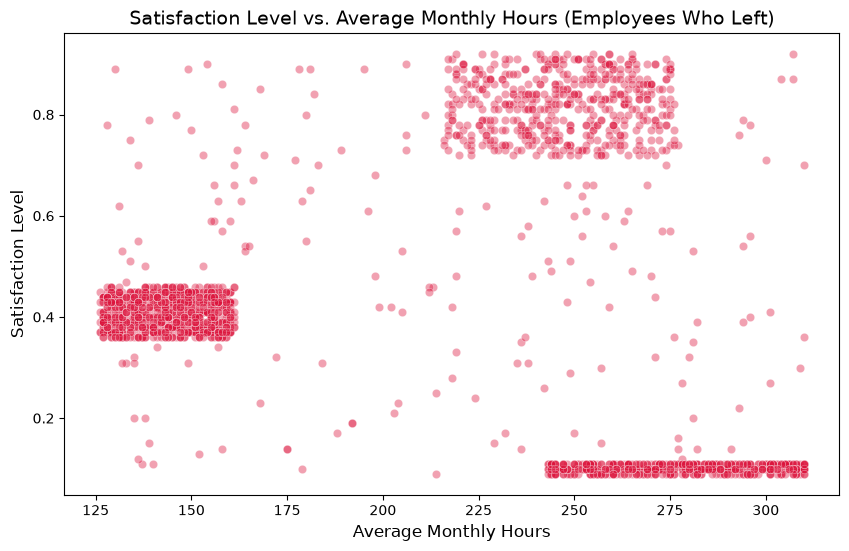

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("HR_comma_sep.csv")
df.columns = df.columns.str.strip()
df = df.drop_duplicates()


sat_col = df.iloc[:, 0]
hours_col = df.iloc[:, 3]
left_col = df.iloc[:, 6]


x_hours = hours_col[left_col == 1].values
y_sat = sat_col[left_col == 1].values


plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_hours, y=y_sat, alpha=0.4, color='crimson')

plt.title('Satisfaction Level vs. Average Monthly Hours (Employees Who Left)', fontsize=14)
plt.xlabel('Average Monthly Hours', fontsize=12)
plt.ylabel('Satisfaction Level', fontsize=12)
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

df_encoded=pd.get_dummies(df, drop_first=True)

X= df_encoded.drop(columns=['left'])
y=df_encoded['left']

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model= RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred=model.predict(X_test)

print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 98.58%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2001
           1       0.99      0.92      0.96       398

    accuracy                           0.99      2399
   macro avg       0.99      0.96      0.97      2399
weighted avg       0.99      0.99      0.99      2399



<function matplotlib.pyplot.show(close=None, block=None)>

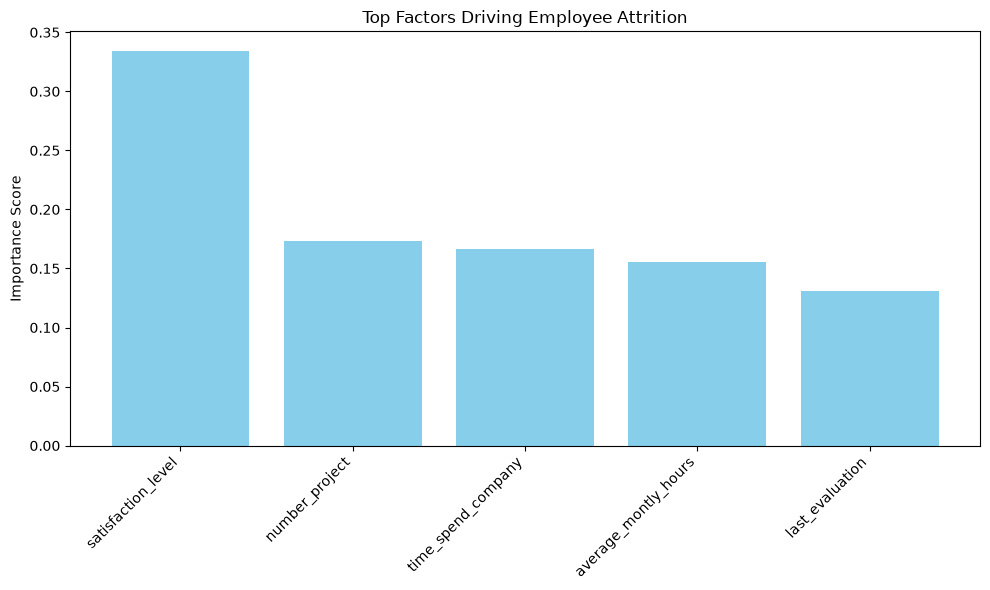

In [14]:
import matplotlib.pyplot as plt
import numpy as np

importances= model.feature_importances_
indices=np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Top Factors Driving Employee Attrition")
plt.bar(range(5), importances[indices[:5]], align="center", color="skyblue")
plt.xticks(range(5), [X.columns[i] for i in indices[:5]], rotation=45, ha='right')
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show


### 🚀 Project Executive Summary: Predictive Attrition Modeling

#### 📊 Model Performance
* Trained a *Random Forest Classifier* achieving a final model accuracy of *98.58%*.
* The model demonstrates strong predictive power for departing staff, securing a *92% recall rate* for identifying employees likely to exit.

#### 💡 Key Business Insights
1. *Employee Satisfaction is Key:* Low job satisfaction is the single strongest indicator of whether an employee will resign.
2. *Project Workload Balances:* The number of assigned projects heavily dictates turnover. Employees given too few or too many projects form highly predictable flight-risk clusters.

#### 🛠️ Strategic Recommendations
* *Proactive Interventions:* Use this model's risk scores monthly to alert HR of high-probability flight risks before they hand in their resignation.
* *Workload Optimization:* Monitor employees assigned to 6+ projects (burnout risk) or fewer than 3 projects (boredom/disengagement risk) to optimize team retention.

In [15]:
import joblib 
joblib.dump(model, 'random_forest_attrition_model.pkl')

print("Model saved successfully as 'random_forest_attrition_model.pkl'!")

Model saved successfully as 'random_forest_attrition_model.pkl'!
